<a href="https://colab.research.google.com/github/nur21horin/machine_learning/blob/main/Heart_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
df=pd.read_csv('/content/Heart.csv',sep=',')

In [10]:
df.head()

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [11]:
df.shape

(303, 15)

In [12]:
df=df.drop('Unnamed: 0',axis=1)

In [14]:
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [13]:
df.describe()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000
mean,54.438944,0.679868,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241
std,9.038662,0.467299,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438
min,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000


In [15]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPain,0
RestBP,0
Chol,0
Fbs,0
RestECG,0
MaxHR,0
ExAng,0
Oldpeak,0


In [17]:
df['Ca'].fillna(df['Ca'].mode()[0],inplace=True)
df['Thal'].fillna(df['Thal'].mode()[0],inplace=True)

/tmp/ipykernel_1218/54574033.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Ca'].fillna(df['Ca'].mode()[0],inplace=True)


In [20]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPain,0
RestBP,0
Chol,0
Fbs,0
RestECG,0
MaxHR,0
ExAng,0
Oldpeak,0


In [24]:
df_encoded = pd.get_dummies(df, columns=['ChestPain', 'Thal', 'AHD'], drop_first=True)
df_encoded.corr()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable,AHD_Yes
Age,1.000000,-0.097542,0.284946,0.208950,0.118530,0.148868,-0.393806,0.091661,0.203805,0.161770,0.365323,-0.051714,-0.151684,0.045438,-0.132264,0.104902,0.223120
Sex,-0.097542,1.000000,-0.064456,-0.199915,0.047862,0.021647,-0.048663,0.146201,0.102173,0.037533,0.086048,-0.117189,-0.037990,0.089828,-0.387396,0.326284,0.276816
RestBP,0.284946,-0.064456,1.000000,0.130120,0.175340,0.146560,-0.045351,0.064762,0.189171,0.117382,0.097528,-0.050127,-0.083234,0.149737,-0.139782,0.106210,0.150825
Chol,0.208950,-0.199915,0.130120,1.000000,0.009841,0.171043,-0.003432,0.061310,0.046564,-0.004062,0.123726,-0.033223,-0.016453,-0.053021,-0.006479,0.053100,0.085164
Fbs,0.118530,0.047862,0.175340,0.009841,1.000000,0.069564,-0.007854,0.025665,0.005747,0.059894,0.140764,0.087027,-0.060649,0.055511,-0.073766,0.030953,0.025264
RestECG,0.148868,0.021647,0.146560,0.171043,0.069564,1.000000,-0.083389,0.084867,0.114133,0.133946,0.131749,-0.089526,-0.102979,0.065581,-0.028989,0.007905,0.169202
MaxHR,-0.393806,-0.048663,-0.045351,-0.003432,-0.007854,-0.083389,1.000000,-0.378103,-0.343085,-0.385601,-0.265699,0.159876,0.249415,0.079683,0.285812,-0.214326,-0.417167
ExAng,0.091661,0.146201,0.064762,0.061310,0.025665,0.084867,-0.378103,1.000000,0.288223,0.257748,0.145788,-0.266871,-0.233863,-0.093384,-0.324082,0.300223,0.431894
Oldpeak,0.203805,0.102173,0.189171,0.046564,0.005747,0.114133,-0.343085,0.288223,1.000000,0.577537,0.301067,-0.126339,-0.277513,0.086959,-0.345731,0.302145,0.424510
Slope,0.161770,0.037533,0.117382,-0.004062,0.059894,0.133946,-0.385601,0.257748,0.577537,1.000000,0.110803,-0.103004,-0.202807,0.064509,-0.301252,0.217318,0.339213


In [26]:
df['AHD'].value_counts()

,count
AHD,
No,164
Yes,139


In [27]:
import seaborn as sns

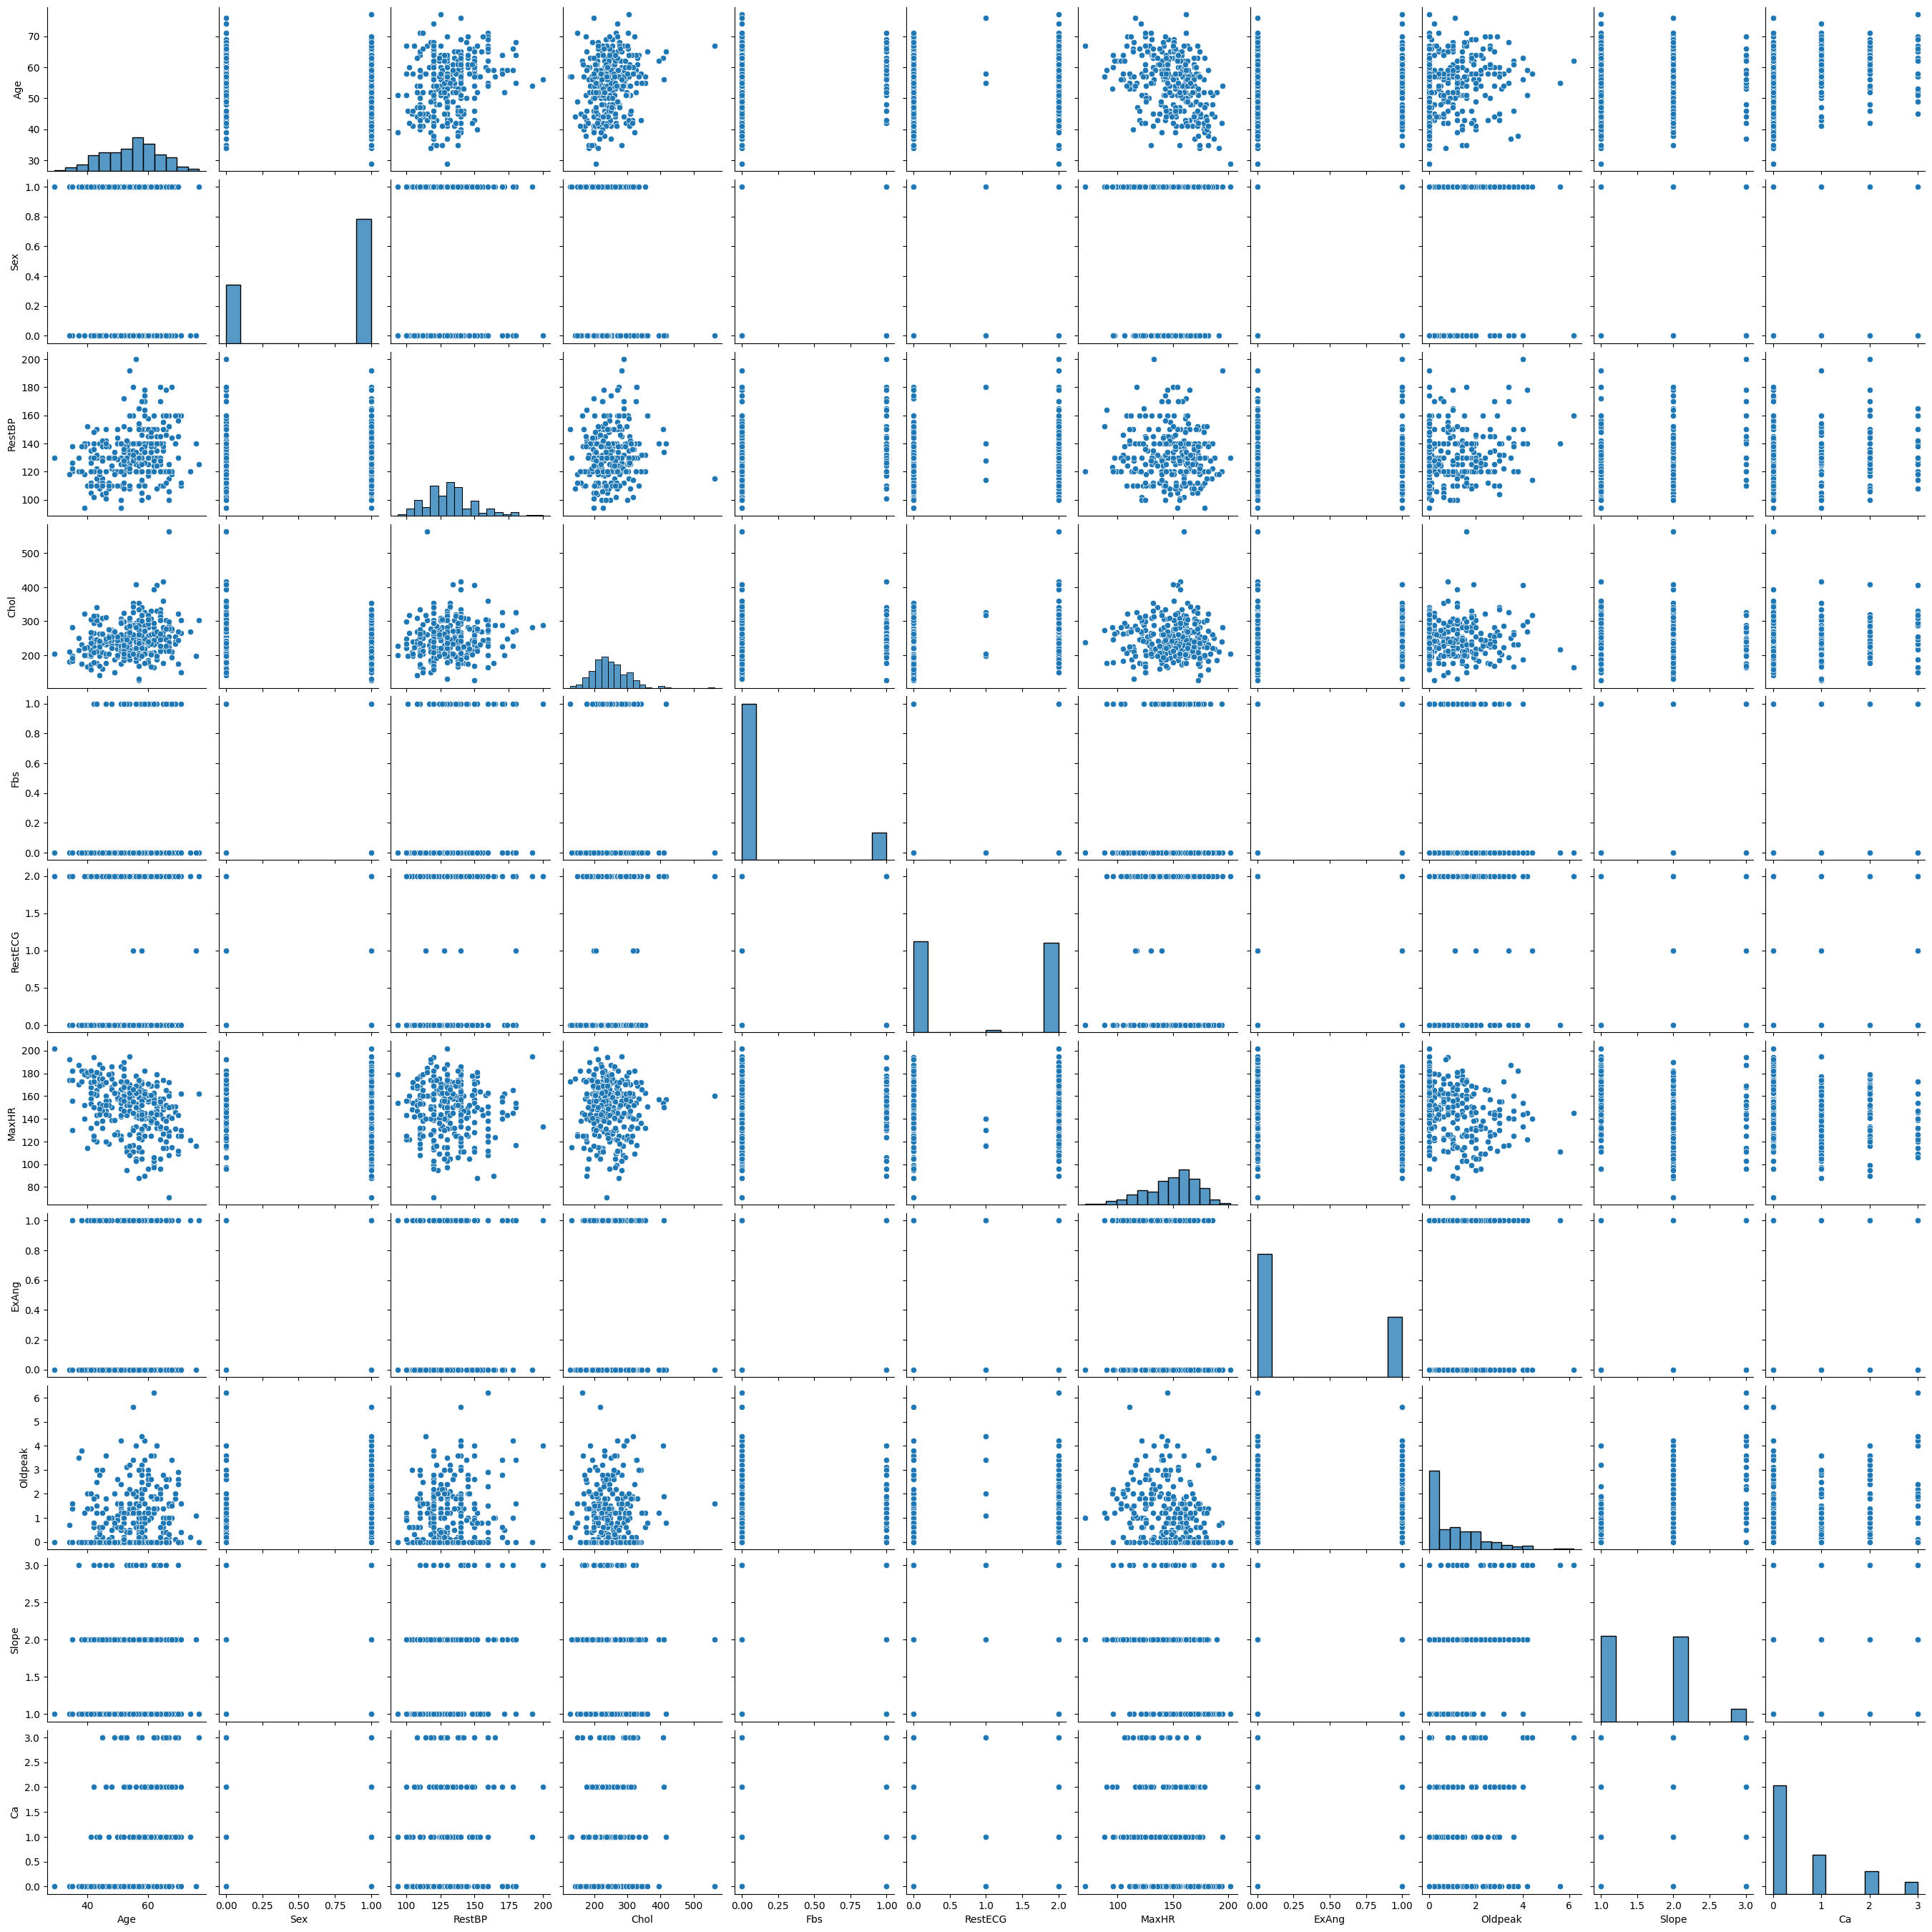

In [29]:
sns.pairplot(df)

<Axes: xlabel='AHD', ylabel='count'>

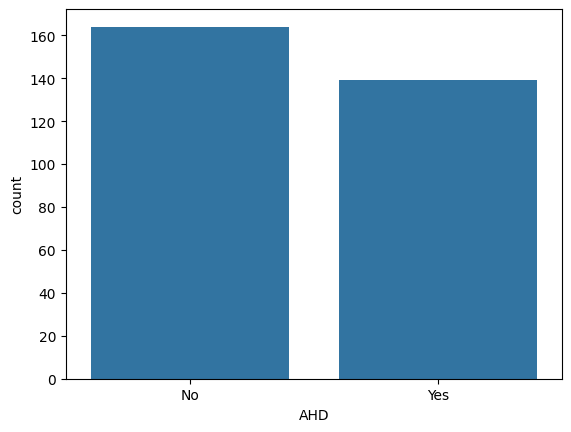

In [30]:
sns.countplot(x='AHD',data=df)

<Axes: xlabel='Thal', ylabel='count'>

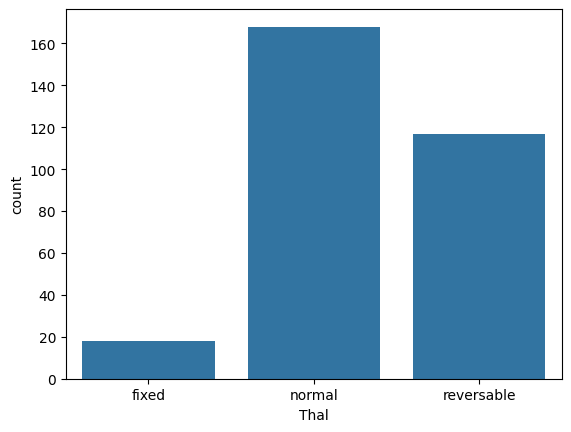

In [31]:
sns.countplot(x='Thal',data=df)

<Axes: xlabel='ChestPain', ylabel='count'>

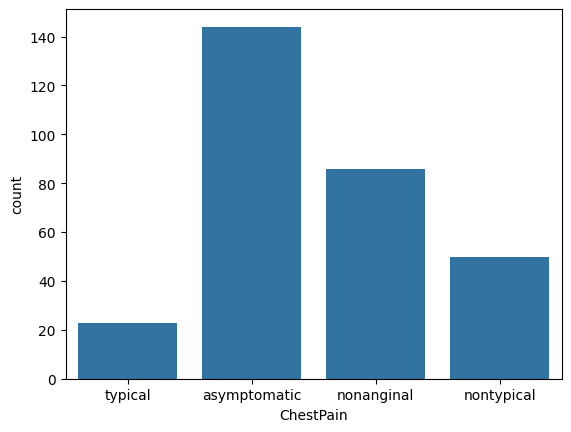

In [32]:
sns.countplot(x='ChestPain',data=df)

<Axes: xlabel='Age', ylabel='Count'>

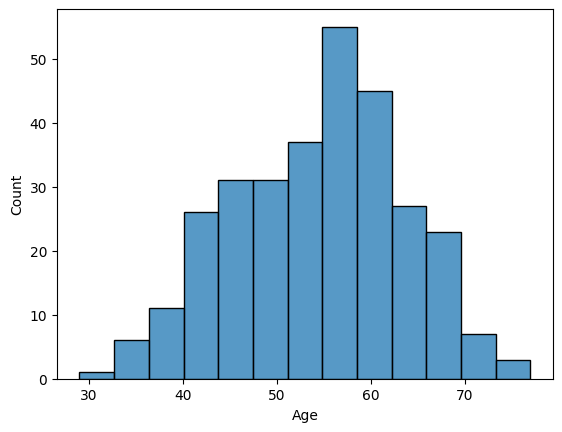

In [35]:
sns.histplot(data=df, x="Age")

In [37]:
df['yr']=(df['Age']/365).round(0)

In [38]:
df['yr']

,yr
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
298,0.0
299,0.0
300,0.0
301,0.0


In [39]:
df.drop(['Age'],axis=1)

,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD,yr
0,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No,0.0
1,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes,0.0
2,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes,0.0
3,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No,0.0
4,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes,0.0
299,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes,0.0
300,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes,0.0
301,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes,0.0


array([[<Axes: title={'center': 'Age'}>, <Axes: title={'center': 'Sex'}>,
        <Axes: title={'center': 'RestBP'}>],
       [<Axes: title={'center': 'Chol'}>,
        <Axes: title={'center': 'Fbs'}>,
        <Axes: title={'center': 'RestECG'}>],
       [<Axes: title={'center': 'MaxHR'}>,
        <Axes: title={'center': 'ExAng'}>,
        <Axes: title={'center': 'Oldpeak'}>],
       [<Axes: title={'center': 'Slope'}>,
        <Axes: title={'center': 'Ca'}>, <Axes: title={'center': 'yr'}>]],
      dtype=object)

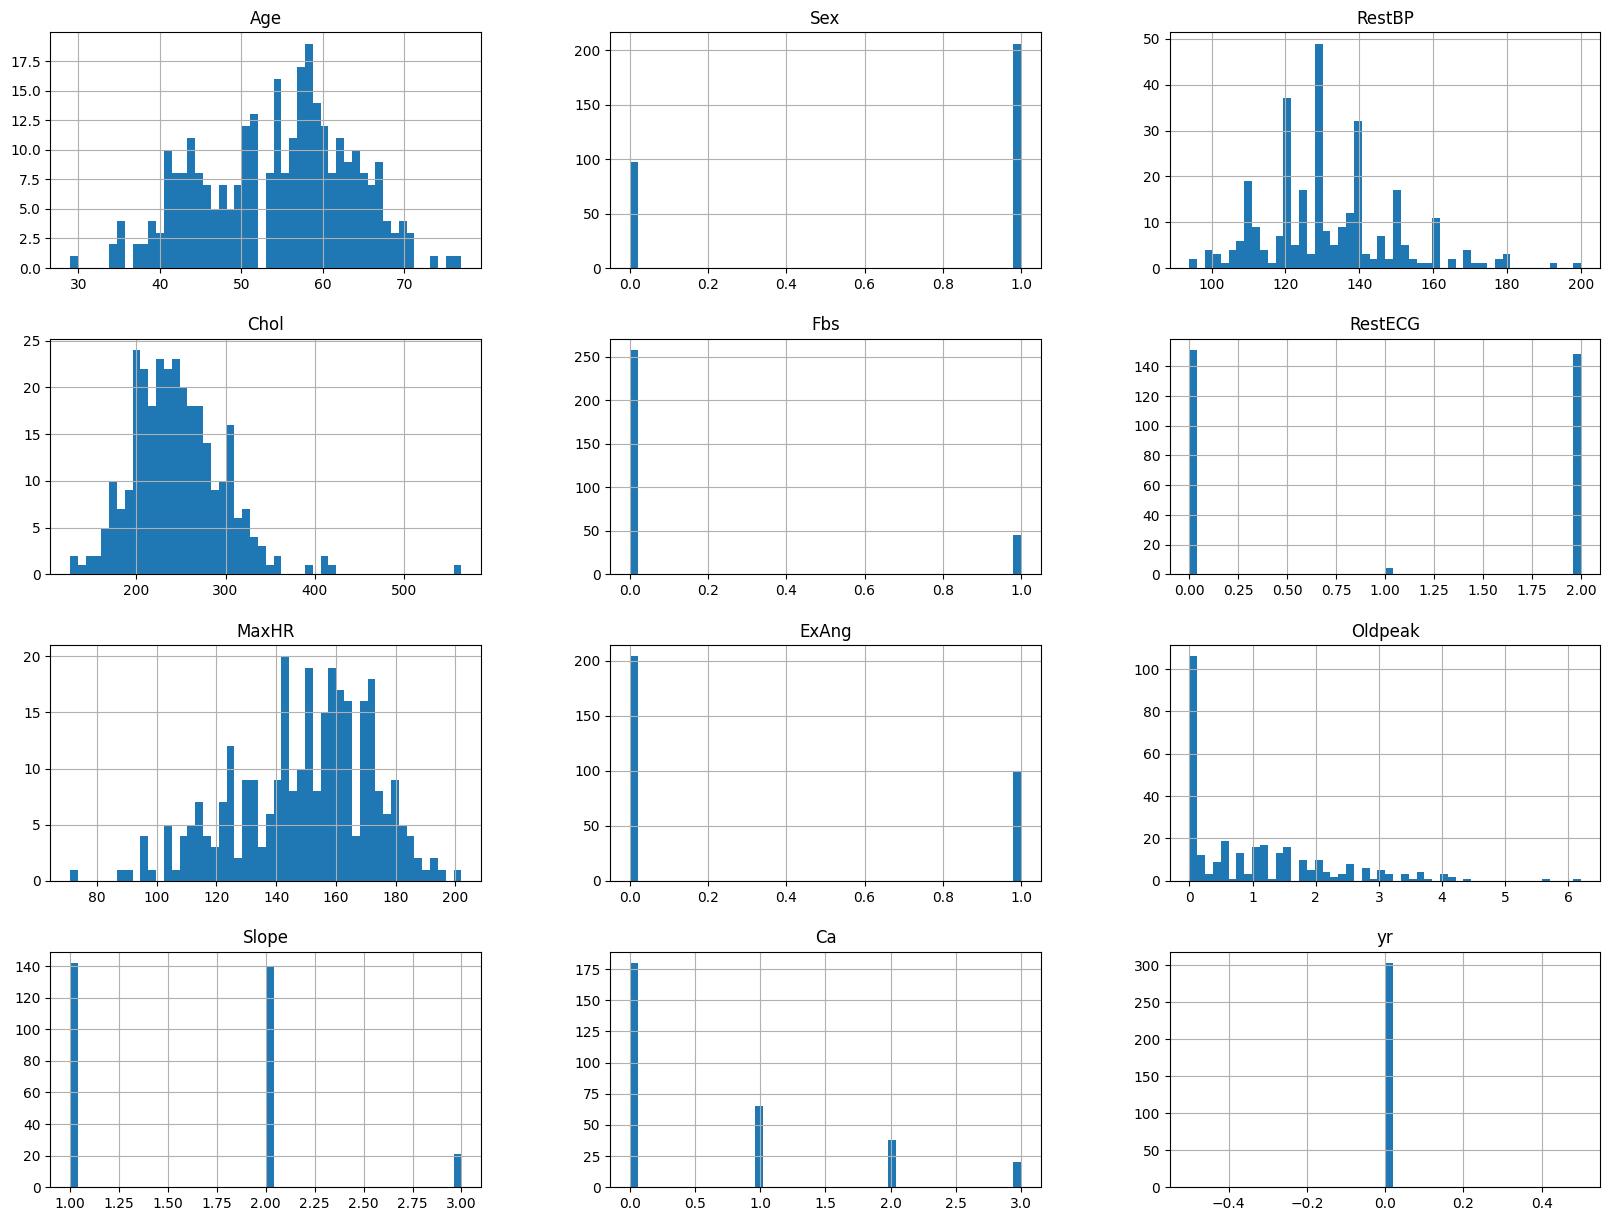

In [40]:
df.hist(bins=50,figsize=(20,15))

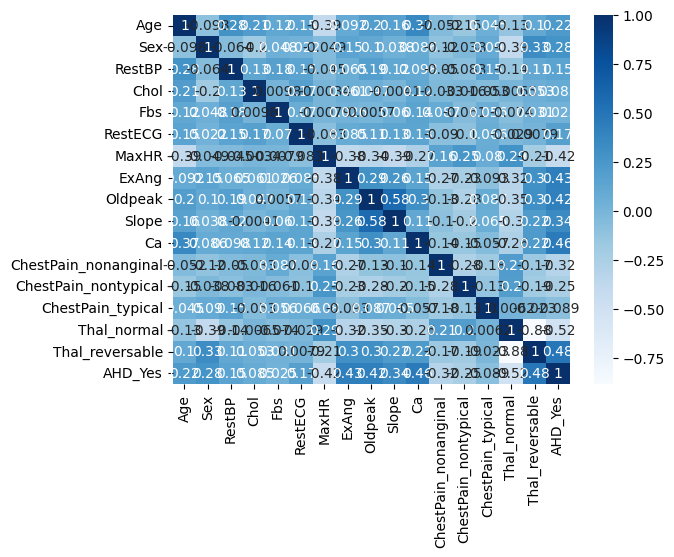

In [42]:
ax=sns.heatmap(data=df_encoded.corr(),cmap='Blues',annot=True)

In [45]:
x=df_encoded[['Sex','RestBP','Chol','Fbs','RestECG','MaxHR','ExAng','Oldpeak','Slope','Ca','Thal_normal','Thal_reversable']]

In [46]:
x

,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal_normal,Thal_reversable
0,1,145,233,1,2,150,0,2.3,3,0.0,False,False
1,1,160,286,0,2,108,1,1.5,2,3.0,True,False
2,1,120,229,0,2,129,1,2.6,2,2.0,False,True
3,1,130,250,0,0,187,0,3.5,3,0.0,True,False
4,0,130,204,0,2,172,0,1.4,1,0.0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
298,1,110,264,0,0,132,0,1.2,2,0.0,False,True
299,1,144,193,1,0,141,0,3.4,2,2.0,False,True
300,1,130,131,0,0,115,1,1.2,2,1.0,False,True
301,0,130,236,0,2,174,0,0.0,2,1.0,True,False


In [48]:
y=df[['AHD']]

In [49]:
y

,AHD
0,No
1,Yes
2,Yes
3,No
4,No
...,...
298,Yes
299,Yes
300,Yes
301,Yes


In [50]:
from sklearn.feature_selection import SelectKBest

In [51]:
from sklearn.feature_selection import f_classif

In [52]:
Fit_feature=SelectKBest(score_func=f_classif)

In [53]:
Fit_feature.fit(x,y)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SelectKBest()

In [54]:
score_col=pd.DataFrame(Fit_feature.scores_,columns=['score_value'])

In [55]:
score_col

,score_value
0,24.978872
1,7.006632
2,2.199054
3,0.192237
4,8.871394
5,63.419223
6,69.020891
7,66.166707
8,39.138194
9,80.800610


In [56]:
Name_col=pd.DataFrame(x.columns)

In [57]:
top_features=pd.concat([Name_col,score_col],axis=1)

In [58]:
top_features.nlargest(8,'score_value')

,0,score_value
10,Thal_normal,111.924663
11,Thal_reversable,90.396519
9,Ca,80.800610
6,ExAng,69.020891
7,Oldpeak,66.166707
5,MaxHR,63.419223
8,Slope,39.138194
0,Sex,24.978872


In [61]:
selected_features = top_features.nlargest(8, 'score_value')[0].tolist()
x = x[selected_features]

In [62]:
x

,Thal_normal,Thal_reversable,Ca,ExAng,Oldpeak,MaxHR,Slope,Sex
0,False,False,0.0,0,2.3,150,3,1
1,True,False,3.0,1,1.5,108,2,1
2,False,True,2.0,1,2.6,129,2,1
3,True,False,0.0,0,3.5,187,3,1
4,True,False,0.0,0,1.4,172,1,0
...,...,...,...,...,...,...,...,...
298,False,True,0.0,0,1.2,132,2,1
299,False,True,2.0,0,3.4,141,2,1
300,False,True,1.0,1,1.2,115,2,1
301,True,False,1.0,0,0.0,174,2,0


In [63]:
from sklearn.model_selection import train_test_split

In [64]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [65]:
from sklearn.ensemble import RandomForestClassifier

In [66]:
rfc=RandomForestClassifier(n_estimators=50)

In [67]:
rfc.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(n_estimators=50)

In [69]:
rfc.score(x_test,y_test)

0.8032786885245902